In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.special import rel_entr
import networkx as nx
from sklearn.metrics import r2_score

import os
import json

from biological_fuzzy_logic_networks.manuscripts_functions.colors import perturbation_models_dict
from biological_fuzzy_logic_networks.manuscripts_functions.metrics import compute_scalar_mmd, wasserstein_distance

In [2]:
fontsize = 12

In [3]:
sns.set_theme(font="Arial", style="ticks", rc={"font.size": fontsize,"axes.titlesize":fontsize,"axes.labelsize":fontsize, 
                                               "xtick.labelsize": fontsize, "ytick.labelsize": fontsize, "legend.fontsize": fontsize})
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.size'] = fontsize


In [4]:
folder = "/dccstor/ipc1/CAR/BFN/Model/init_dists/Output/test"
config_folder = "/dccstor/ipc1/CAR/BFN/Model/init_dists/Configs/"

In [5]:
n_repeats = 5
dists = ["normal", "bimodal", "uniform"]

data = []

for j in range(n_repeats):
    for dist in dists:
        exp_data = pd.read_csv(f"{folder}{dist}_repeat_{j}_predictions.csv", index_col=1)
        exp_data = exp_data.rename(columns={"Unnamed: 0":"model"})
        exp_data["dist"] = dist
        exp_data["repeat"] = j
        data.append(exp_data)
        
        

In [6]:
data = pd.concat(data)

In [7]:
data

,model,mek12,erk12,mkk4,jnk12,ikk,ikb,ras,map3k7,pi3k,map3k1,akt,p38,hsp27,dist,repeat
0,teacher_true,0.015154,0.006483,0.136310,0.089075,0.586699,0.692869,0.030757,0.575837,0.686322,0.514185,0.833198,0.039347,0.006685,normal,0
1,teacher_true,0.015529,0.006647,0.997001,0.999999,1.000000,1.000000,0.031487,0.994639,0.999998,0.983968,1.000000,0.999927,0.999872,normal,0
2,teacher_true,0.298404,0.192599,0.042195,0.027668,0.438653,0.499102,0.370596,0.535708,0.859069,0.262885,0.975283,0.009720,0.001804,normal,0
3,teacher_true,0.216989,0.123742,0.003423,0.001693,0.110473,0.106239,0.299266,0.263376,0.380969,0.092056,0.399948,0.000269,0.000019,normal,0
4,teacher_true,0.117391,0.057853,0.848300,0.899377,0.998776,0.999998,0.190194,0.836868,0.963993,0.934757,0.999196,0.846949,0.735863,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,nohill_random_input,0.024982,0.013914,0.109772,0.084664,0.453078,0.320224,0.044415,0.549401,0.520881,0.391013,0.383958,0.026335,0.006165,uniform,4
996,nohill_random_input,0.270638,0.171849,0.901083,0.946324,0.990159,0.987677,0.396277,0.961382,0.934017,0.966089,0.904259,0.808079,0.704764,uniform,4
997,nohill_random_input,0.072193,0.041189,0.025237,0.020071,0.364575,0.244358,0.123211,0.481548,0.648773,0.124287,0.519371,0.004869,0.000992,uniform,4
998,nohill_random_input,0.052734,0.029787,0.544524,0.448590,0.773940,0.673885,0.091507,0.806249,0.524130,0.835734,0.387144,0.292366,0.137570,uniform,4


In [8]:
output_markers = [c for c in data.columns if c not in ["model", "dist", "repeat"]]
markers = [
        "mek12",
        "erk12",
        "mkk4",
        "jnk12",
        "ikk",
        "ikb",
        "ras",
        "map3k7",
        "igf1",
        "pi3k",
        "il1a",
        "map3k1",
        "tgfa",
        "tnfa",
        "akt",
        "p38",
        "hsp27",
    ]

In [9]:
def compute_MSE(data, true_model_name: str):
    true = data[data["model"]==true_model_name]
    true = true.drop(["model", "dist", "repeat"], axis=1)
    true["repeat"] = 0 # So that repeat doesn't get lost when x-true. This doesn't cancel out the different repeats
    data = data.groupby("model").apply(lambda x: ((x-true)**2).groupby("repeat").mean())
    data = data.drop(["model", "dist"], axis=1)
    data = data.reset_index("model", drop=False)
    
    return data

def compute_R2(data, true_model_name: str, markers=output_markers):
    true = data[data["model"]==true_model_name]
    data = data.groupby("model").apply(lambda x: pd.Series([r2_score(true[m], x[m]) for m in markers]))
    data.columns=markers
    data[data==np.inf] = 0
    data = data.reset_index(drop=False)
    
    return data


def compute_MMD(data, true_model_name: str, markers=output_markers):
    true = data.loc[data["model"]==true_model_name, markers]
    data = data.groupby("model").apply(lambda x: compute_scalar_mmd(true, x[markers]))
    data = data.reset_index(drop=False)
    
    return data

def compute_wasserstein(data, true_model_name: str, markers=output_markers):
    true = data.loc[data["model"]==true_model_name, markers]
    data = data.groupby("model").apply(lambda x: wasserstein_distance(true, x[markers]))
    data = data.reset_index(drop=False)
    
    return data

In [10]:
data["model"].unique()

array(['teacher_true', 'student_same_input', 'student_random_input',
       'nohill_same_input', 'nohill_random_input'], dtype=object)

In [11]:
data_MSE = data.groupby(["dist"]).apply(compute_MSE, true_model_name="teacher_true").reset_index()
data_R2 = data.groupby(["dist", "repeat"]).apply(compute_R2, true_model_name="teacher_true").reset_index().drop("level_2", axis=1)

data_MMD = data.groupby(["dist", "repeat"]).apply(compute_MMD, true_model_name="teacher_true").reset_index().drop("level_2", axis=1).rename(columns={0: "MMD"})
data_EMD = data.groupby(["dist", "repeat"]).apply(compute_wasserstein, true_model_name="teacher_true").reset_index().drop("level_2", axis=1).rename(columns={0: "EMD"})
data_EMD["EMD"] = data_EMD["EMD"].astype(float)


2025-03-11 05:21:29.531378: W external/xla/xla/service/platform_util.cc:198] unable to create StreamExecutor for CUDA:0: failed initializing StreamExecutor for CUDA device ordinal 0: INTERNAL: failed call to cuDevicePrimaryCtxRetain: CUDA_ERROR_DEVICE_UNAVAILABLE: CUDA-capable device(s) is/are busy or unavailable
CUDA backend failed to initialize: INTERNAL: no supported devices found for platform CUDA (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [12]:
avg_data_MSE = data_MSE.groupby(["dist", "model", "repeat"]).mean().reset_index()
avg_data_R2 = data_R2.groupby(["dist", "model", "repeat"]).mean().reset_index()
avg_data_MSE = avg_data_MSE.melt(id_vars=["dist", "model", "repeat"], value_name="Network MSE", var_name="node")
avg_data_R2 = avg_data_R2.melt(id_vars=["dist", "model", "repeat"], value_name="Network R2", var_name="node")
avg_data_MSE = avg_data_MSE.groupby(["dist", "model", "repeat"]).mean().reset_index()
avg_data_R2 = avg_data_R2.groupby(["dist", "model", "repeat"]).mean().reset_index()

avg_data_MSE

,dist,model,repeat,Network MSE
0,bimodal,nohill_random_input,0,0.218580
1,bimodal,nohill_random_input,1,0.218813
2,bimodal,nohill_random_input,4,0.201351
3,bimodal,nohill_random_input,9,0.221480
4,bimodal,nohill_random_input,16,0.193484
...,...,...,...,...
70,uniform,teacher_true,0,0.000000
71,uniform,teacher_true,1,0.000000
72,uniform,teacher_true,4,0.000000
73,uniform,teacher_true,9,0.000000


# MSE, same inputs

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


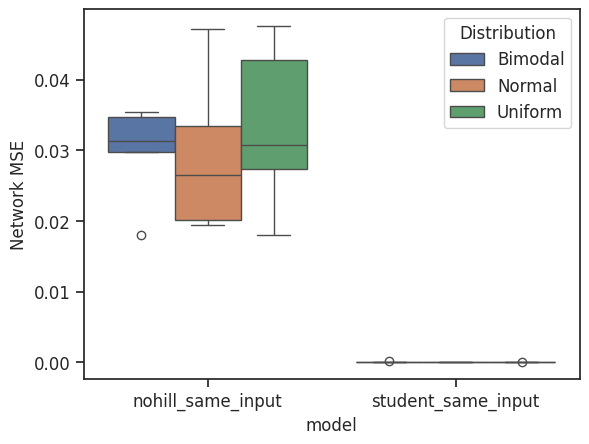

In [13]:
plt_data = avg_data_MSE[avg_data_MSE["model"].isin(['student_same_input', 'nohill_same_input'])]
g = sns.boxplot(data=plt_data, x="model", y="Network MSE", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_MSE_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")

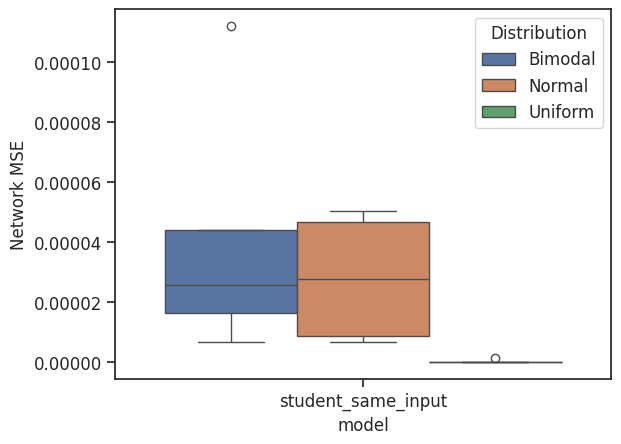

In [14]:
plt_data = avg_data_MSE[avg_data_MSE["model"]=='student_same_input']
g=sns.boxplot(data=plt_data, x="model", y="Network MSE", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_MSE_boxplot_student_same_inputs_three_dists.pdf", bbox_inches="tight")

# R2, same inputs

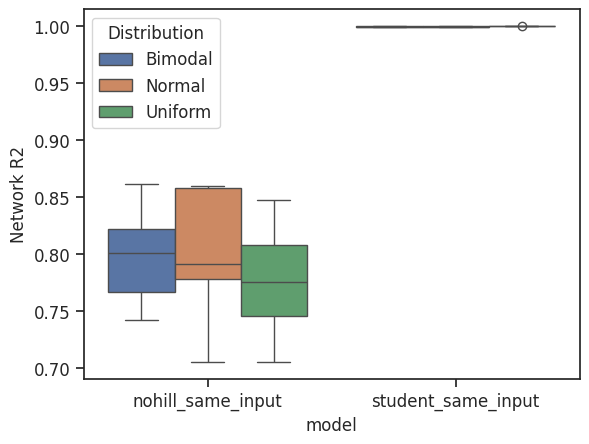

In [15]:
plt_data = avg_data_R2[avg_data_R2["model"].isin(['student_same_input', 'nohill_same_input'])]
g=sns.boxplot(data=plt_data, x="model", y="Network R2", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_R2_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")

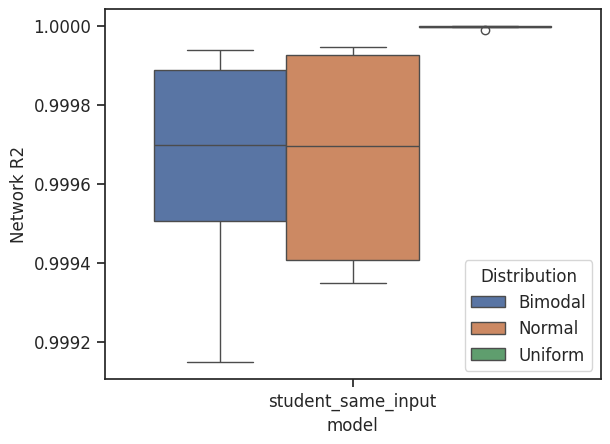

In [16]:
plt_data = avg_data_R2[avg_data_R2["model"]=='student_same_input']
g=sns.boxplot(data=plt_data, x="model", y="Network R2", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_R2_boxplot_student_same_inputs_three_dists.pdf", bbox_inches="tight")

# MMD, all random and same inputs

In [17]:
data_MMD

,dist,repeat,model,MMD
0,bimodal,0,nohill_random_input,4.057161e-02
1,bimodal,0,nohill_same_input,3.835791e-02
2,bimodal,0,student_random_input,1.317360e-03
3,bimodal,0,student_same_input,1.516690e-05
4,bimodal,0,teacher_true,0.000000e+00
...,...,...,...,...
70,uniform,4,nohill_random_input,5.349639e-02
71,uniform,4,nohill_same_input,5.334525e-02
72,uniform,4,student_random_input,8.074467e-04
73,uniform,4,student_same_input,3.327926e-07


/tmp/ipykernel_2426639/94421533.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels(labels=["NoHill Random input", "NoHill same input", "Student random input", "Student same input"])


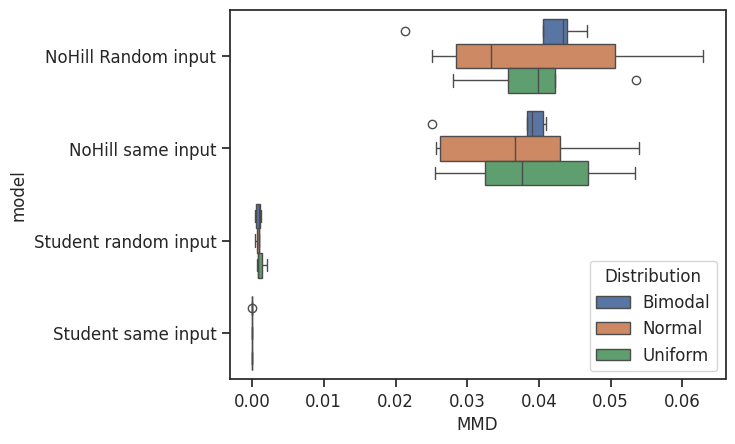

In [20]:
plt_data = data_MMD[data_MMD["model"]!="teacher_true"]
g=sns.boxplot(data=plt_data, y="model", x="MMD", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
g.set_yticklabels(labels=["NoHill Random input", "NoHill same input", "Student random input", "Student same input"])
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_MMD_boxplot_all_inputs_three_dists.pdf", bbox_inches="tight")

/tmp/ipykernel_2426639/1490158380.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels(labels=["Student random input", "Student same input"])


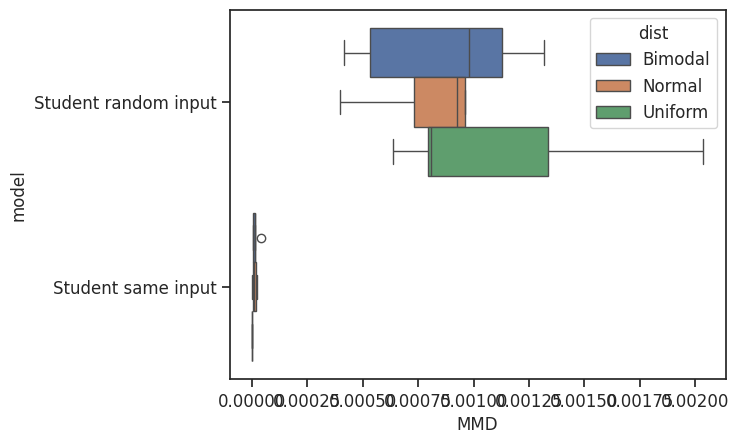

In [21]:
plt_data = data_MMD[data_MMD["model"].isin(['student_same_input', 'student_random_input'])]
g=sns.boxplot(data=plt_data, y="model", x="MMD", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
g.set_yticklabels(labels=["Student random input", "Student same input"])
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_MMD_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")

# EMD, all random and same inputs

/tmp/ipykernel_2426639/3649492231.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels(labels=["NoHill Random input", "NoHill same input", "Student random input", "Student same input"])


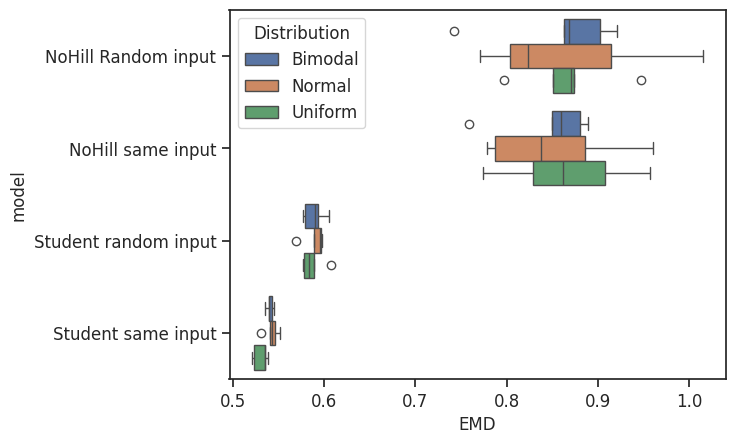

In [23]:
plt_data = data_EMD[data_EMD["model"]!="teacher_true"]
g= sns.boxplot(data=plt_data, y="model", x="EMD", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
g.set_yticklabels(labels=["NoHill Random input", "NoHill same input", "Student random input", "Student same input"])
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_EMD_boxplot_all_inputs_three_dists.pdf", bbox_inches="tight")

/tmp/ipykernel_2426639/443602551.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels(labels=["Student random input", "Student same input"])


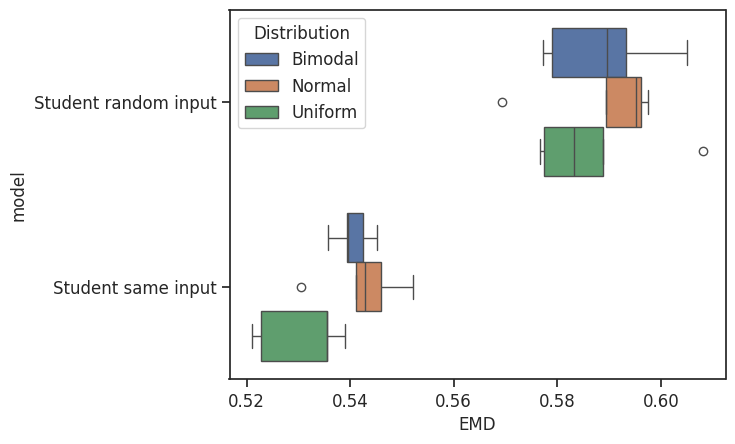

In [24]:
plt_data = data_EMD[data_EMD["model"].isin(['student_same_input', 'student_random_input'])]
g=sns.boxplot(data=plt_data, y="model", x="EMD", hue="dist")
plt.legend(title="Distribution")
new_labels = ["Bimodal", "Normal", "Uniform"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
g.set_yticklabels(labels=["Student random input", "Student same input"])
plt.savefig("/dccstor/ipc1/CAR/BFN/Figures/Init_distributions_EMD_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")